In [21]:
df_raw.columns.to_list #pour voir les noms des colonnes

<bound method IndexOpsMixin.tolist of Index(['BEGIN_YEARMONTH', 'BEGIN_DAY', 'BEGIN_TIME', 'END_YEARMONTH',
       'END_DAY', 'END_TIME', 'EPISODE_ID', 'EVENT_ID', 'STATE', 'STATE_FIPS',
       'YEAR', 'MONTH_NAME', 'EVENT_TYPE', 'CZ_TYPE', 'CZ_FIPS', 'CZ_NAME',
       'WFO', 'BEGIN_DATE_TIME', 'CZ_TIMEZONE', 'END_DATE_TIME',
       'INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT',
       'DEATHS_INDIRECT', 'DAMAGE_PROPERTY', 'DAMAGE_CROPS', 'SOURCE',
       'MAGNITUDE', 'MAGNITUDE_TYPE', 'FLOOD_CAUSE', 'CATEGORY', 'TOR_F_SCALE',
       'TOR_LENGTH', 'TOR_WIDTH', 'TOR_OTHER_WFO', 'TOR_OTHER_CZ_STATE',
       'TOR_OTHER_CZ_FIPS', 'TOR_OTHER_CZ_NAME', 'BEGIN_RANGE',
       'BEGIN_AZIMUTH', 'BEGIN_LOCATION', 'END_RANGE', 'END_AZIMUTH',
       'END_LOCATION', 'BEGIN_LAT', 'BEGIN_LON', 'END_LAT', 'END_LON',
       'EPISODE_NARRATIVE', 'EVENT_NARRATIVE', 'DATA_SOURCE'],
      dtype='object')>

(11761, 51)
       BEGIN_DATE_TIME      STATE  MAGNITUDE DAMAGE_PROPERTY
17  24-OCT-23 08:59:00  WISCONSIN       1.00           0.00K
18  24-OCT-23 09:36:00  WISCONSIN       0.88           0.00K
22  24-OCT-23 09:07:00  WISCONSIN       1.75           0.00K
24  24-OCT-23 08:33:00  WISCONSIN       2.25           0.00K
25  06-AUG-23 20:47:00   ILLINOIS       1.25           0.00K
26  24-OCT-23 08:30:00  WISCONSIN       1.00           0.00K
30  06-AUG-23 20:49:00   ILLINOIS       1.00           0.00K
31  24-OCT-23 09:06:00  WISCONSIN       1.25           0.00K
35  06-AUG-23 18:20:00   ILLINOIS       1.00           0.00K
36  06-AUG-23 18:26:00   ILLINOIS       1.75           0.00K
Il y a 4968 évènements avec dégâts, soit 42.2 % du total grêle.


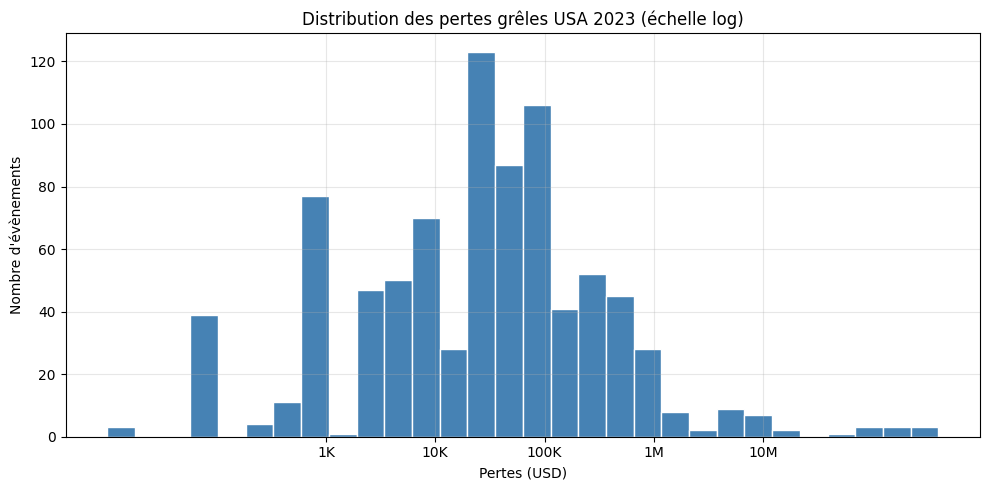

In [91]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#après r ' '
#dataset 2023 téléchargé depuis ncei.noaa.gov
chemin = r'C:\Users\jhmag\Downloads\StormEvents_details-ftp_v1.0_d2023_c20260323.csv.gz'
# pd.read_csv, compression, low_memory
df_raw = pd.read_csv(chemin, compression = 'gzip', low_memory = False)
#que les lignes qui concernent la grêle
df_hail = df_raw[df_raw['EVENT_TYPE'] == 'Hail']
#pour afficher le nombre de lignes et colonnes
print(df_hail.shape)
print(df_hail[['BEGIN_DATE_TIME', 'STATE', 'MAGNITUDE', 'DAMAGE_PROPERTY']].head(10))
#!= différent de
df_hail_damage = df_hail[df_hail['DAMAGE_PROPERTY'] != '0.00K']
#.shape[0] pour le nombre de lignes, f"texte{}"
print(f"Il y a {df_hail_damage.shape[0]} évènements avec dégâts, soit {round(df_hail_damage.shape[0]/df_hail.shape[0]*100,1)} % du total grêle.")
#fct pd.isna
def convertir_damage(valeur):
    if pd.isna(valeur):
        return 0
        
    valeur=str(valeur).strip()
#elif fait qu'a la première condition vrai, la fonction exécute son return sinon elle teste chaque condition
    if valeur.endswith('K'):
        return float(valeur[:-1])*1_000

    elif valeur.endswith('M'):
        return float(valeur[:-1])*1_000_000

    elif valeur.endswith('B'):
        return float(valeur[:-1])*1_000_000_000

    else:
        return float(valeur) if valeur else 0
        
df_hail_damage = df_hail_damage.copy()
#ajoute une colonne dmg usd a partir de dmg property et la fonction appliquée
df_hail_damage['DAMAGE_USD'] = df_hail_damage['DAMAGE_PROPERTY'].apply(convertir_damage)

df_hail_final = df_hail_damage[df_hail_damage['DAMAGE_USD'] > 0]

plt.figure(figsize=(10,5))
plt.hist(np.log10(df_hail_final['DAMAGE_USD']), bins=30, color='steelblue', edgecolor='white')

plt.xticks([3,4,5,6,7],['1K','10K','100K','1M','10M'])
    
    
plt.title('Distribution des pertes grêles USA 2023 (échelle log)')

plt.xlabel('Pertes (USD)')

plt.ylabel("Nombre d'évènements")

plt.grid(True,alpha=0.3)

plt.tight_layout()
plt.show()
